In [ ]:
import pandas as pd
import numpy as np
import risk_kit_daxal as rd
import yfinance as yf
from matplotlib import pyplot as plt
%load_ext autoreload
%autoreload 2


In [2]:
l = ['ITC.NS', 'HINDUNILVR.NS', 'TCS.NS', 'INFY.NS']
data = rd.get_returns(l)

In [3]:
data.head()

,ITC.NS,HINDUNILVR.NS,TCS.NS,INFY.NS
Date,,,,
2012-01-01 00:00:00+05:30,NaN,NaN,NaN,NaN
2012-02-01 00:00:00+05:30,0.018142,0.003298,0.082062,0.050055
2012-03-01 00:00:00+05:30,0.092704,0.078512,-0.043497,-0.005948
2012-04-01 00:00:00+05:30,0.081974,0.018412,0.066564,-0.141018
2012-05-01 00:00:00+05:30,-0.065784,0.024904,-0.001003,-0.013301


In [4]:
rd.summary_stats(data, rf=0.07)

,Annualized Return,Annualized Vol,Skewness,Kurtosis,Sharpe Ratio,Max Drawdown
ITC.NS,0.113940,0.215804,-0.058585,3.354946,0.193246,-0.452902
HINDUNILVR.NS,0.211179,0.216870,0.870418,4.365854,0.614105,-0.243332
TCS.NS,0.195288,0.233004,0.591387,3.274335,0.507319,-0.196099
INFY.NS,0.172113,0.269166,0.020183,4.353688,0.357921,-0.251795


<Axes: xlabel='Date'>

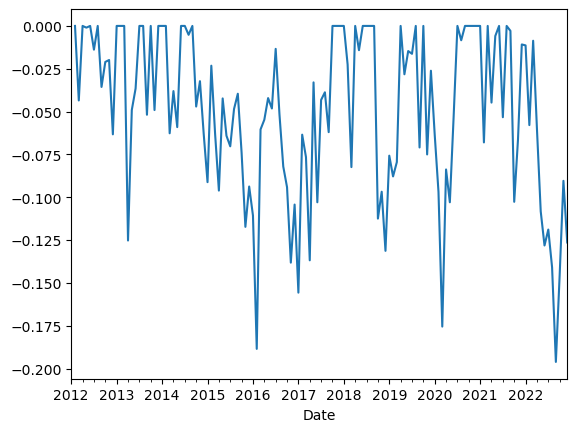

In [5]:
rd.drawdown(data['TCS.NS'])["Drawdown"].plot.line()

<Axes: >

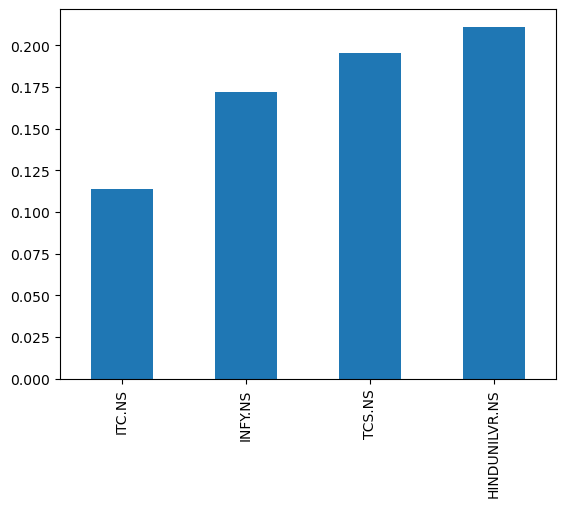

In [6]:
er = rd.annualize_rets(data, 12)
er.sort_values().plot.bar()

<Axes: >

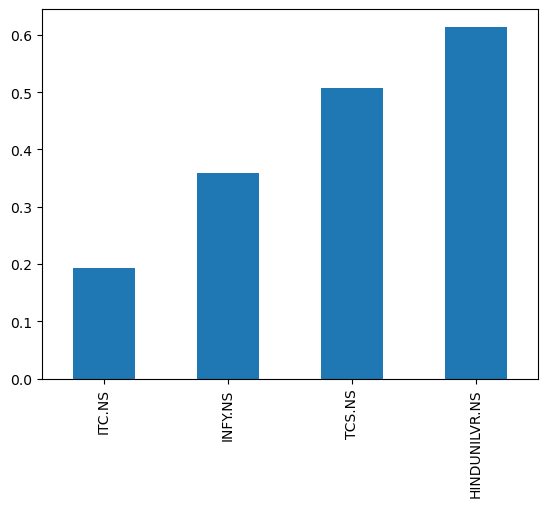

In [7]:
rd.sharpe_ratio(data, rf=0.07, periods_per_year=12).sort_values().plot.bar()

In [8]:
cov = data.cov()
cov

,ITC.NS,HINDUNILVR.NS,TCS.NS,INFY.NS
ITC.NS,0.003881,0.000830,0.000852,0.000469
HINDUNILVR.NS,0.000830,0.003919,0.000477,-0.000309
TCS.NS,0.000852,0.000477,0.004524,0.003088
INFY.NS,0.000469,-0.000309,0.003088,0.006038


<Axes: xlabel='Volatility'>

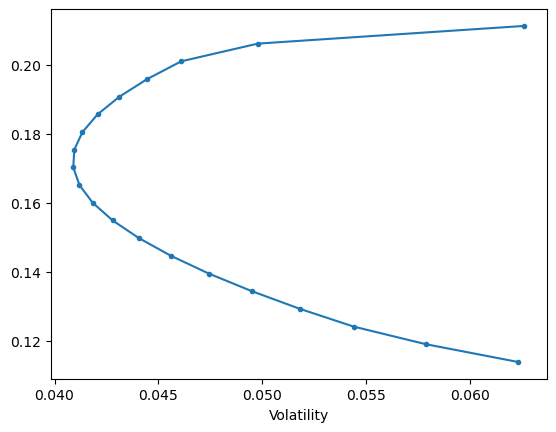

In [9]:
# cols = ['TECHM.NS', 'TCS.NS']
rd.plot_ef(20, er, cov)


#### Let's Find the best Portfolio for target return = 15%

In [10]:
best_weights = rd.minimize_vol(0.15, er, cov)
best_vol = rd.portfolio_vol(best_weights, cov)
best_vol

0.04399765987576471

In [11]:
optimal_weights = rd.msr(0.03, er, cov)
optimal_weights

array([0.0701537 , 0.51265405, 0.24472518, 0.17246707])

<Axes: xlabel='Volatility'>

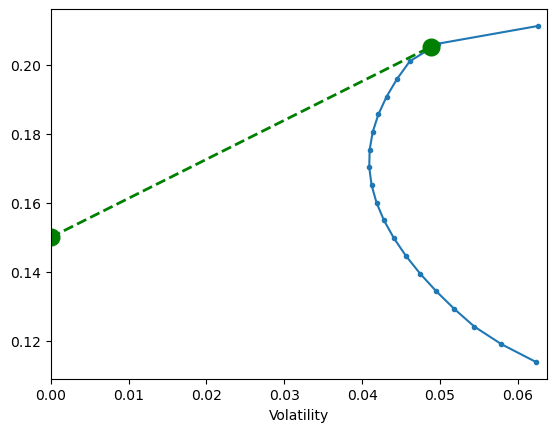

In [12]:
rd.plot_ef2(20, er, cov, show_cml=True, rf=0.15)

In [13]:
optimal_weights 

array([0.0701537 , 0.51265405, 0.24472518, 0.17246707])

### After finding the best stock portfolio with highest Sharpe ratio, we will try to implement further diversification using Constant Proportion Portfolio Insurance (CPPI) strategy.

In [14]:
# optimal_weights = optimal_weights.reshape(-1, 1)
optimal_weights.shape

(4,)

In [15]:
equal_weights = np.repeat(1/data.shape[1], data.shape[1])
equal_weights

array([0.25, 0.25, 0.25, 0.25])

In [16]:
r = rd.optimal_returns(data, optimal_weights)
risky_r = pd.DataFrame(r, columns=['optimal_rets'])
risky_r.dropna(inplace=True)
risky_r.head()

,optimal_rets
Date,
2012-02-01 00:00:00+05:30,0.031679
2012-03-01 00:00:00+05:30,0.035082
2012-04-01 00:00:00+05:30,0.007159
2012-05-01 00:00:00+05:30,0.005613
2012-06-01 00:00:00+05:30,0.055218


In [17]:
cppi_results = rd.run_cppi(risky_r, m=2, start=1000, floor=0.85, rf=0.07)

<Axes: xlabel='Date'>

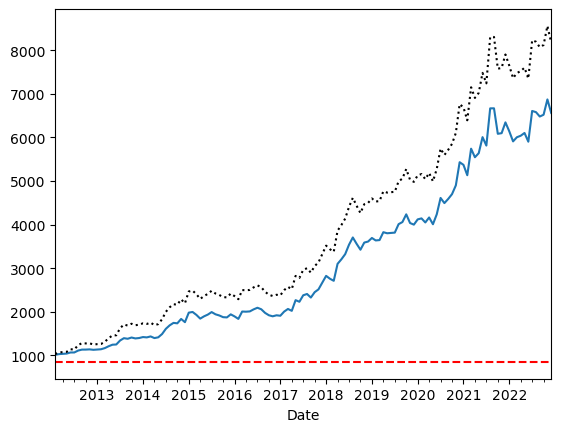

In [18]:
ind = 'optimal_rets'
cppi_results['Wealth'][ind].plot()
cppi_results['floor'][ind].plot(style="r--")
cppi_results['Risky Wealth'][ind].plot(style="k:")